## Exercises from https://github.com/karpathy/micrograd/tree/master

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from graphviz import Digraph

In [5]:
def f(x):
    return 3*x**2 - 4*x + 5

In [6]:
f(3.0)

20.0

In [7]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [8]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

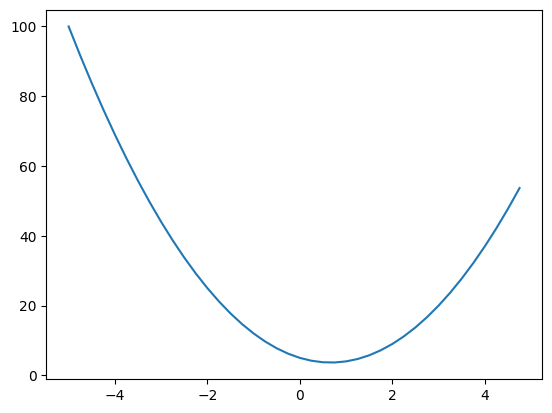

In [9]:
plt.plot(xs, ys)

In [10]:
h = 0.001
x = 3.0
print(f(x))
print(f(x + h))

20.0
20.014003000000002


In [11]:
(f(x + h) - f(x))/h

14.00300000000243

In [12]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [13]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [132]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # This allows operations with int and floats
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # Sum operation propagates the grad of the parent into the children
            self.grad += 1.0 * out.grad # Initially gradients were set with equal, but that created a bug when a variable was used more than
                                        # once. Solution: following multivariate chain rule, we use += to accumulate the gradient.
            other.grad += 1.0 * out.grad 
        out._backward = _backward

        return out
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # See this line's note in __add__
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            # Multiplication operation is equal to the value of the other times the grad of the parent 
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        # a.__mul__(2) != 2.__mul__(a)
        # Adds support for other * self
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports int/float powers"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward

        return out

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other): # other - self
        return other + (-self)
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            # The local derivative of e**x operation is equal to  e**x = out.data
            self.grad += out.data * out.grad 
        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            # The local derivative of tanh operation is equal to  1 - tanh(n)**2 = 1 - o**2
            self.grad += (1 - t**2) * out.grad 
        out._backward = _backward

        return out
    
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def backward(self, verbose=True):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                if verbose:
                    print(f'visiting: {v.label}')
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                if verbose:
                    print(f'Appending {v.label} to topo')
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            if verbose:
                print(f'Calling _backward in {v.label}')
            v._backward()


In [133]:
def trace(root):
    # builds a set of all nodes and edges in graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']

    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this valueis a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    # for n in nodes:
    #     dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
    #     if n._op:
    #         dot.node(name=str(id(n)) + n._op, label=n._op)
    #         dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [134]:
a = Value(2.0)
a

Value(data=2.0, grad=0.0)

In [135]:
a = Value(2.0)
b = Value(-3.0)
a + b

Value(data=-1.0, grad=0.0)

In [136]:
a.__add__(b)

Value(data=-1.0, grad=0.0)

In [137]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10, label='c')
# d = a*b + c
# d._prev
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
l = d*f; l.label = 'L'
l

Value(data=-8.0, grad=0.0)

In [138]:
d._op

'+'

In [139]:
print(d, d._prev, d._op)

Value(data=4.0, grad=0.0) {Value(data=10, grad=0.0), Value(data=-6.0, grad=0.0)} +


In [140]:
print(list(d._prev)[0], list(d._prev)[0]._prev, list(d._prev)[0]._op)

Value(data=10, grad=0.0) set() 


In [141]:
print(list(d._prev)[1], list(d._prev)[1]._prev, list(d._prev)[1]._op)

Value(data=-6.0, grad=0.0) {Value(data=2.0, grad=0.0), Value(data=-3.0, grad=0.0)} *


In [142]:
trace(d)

({Value(data=-3.0, grad=0.0),
  Value(data=-6.0, grad=0.0),
  Value(data=10, grad=0.0),
  Value(data=2.0, grad=0.0),
  Value(data=4.0, grad=0.0)},
 {(Value(data=-3.0, grad=0.0), Value(data=-6.0, grad=0.0)),
  (Value(data=-6.0, grad=0.0), Value(data=4.0, grad=0.0)),
  (Value(data=10, grad=0.0), Value(data=4.0, grad=0.0)),
  (Value(data=2.0, grad=0.0), Value(data=-6.0, grad=0.0))})

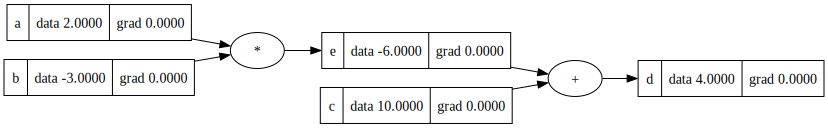

In [143]:
draw_dot(d)

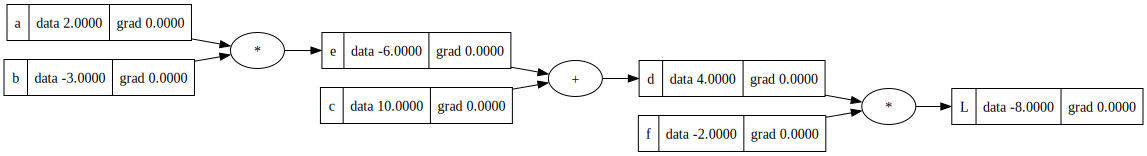

In [144]:
draw_dot(l)

In [145]:
def manual_derivative():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    l = d*f; l.label = 'L'
    l1 = l.data

    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    l = d*f; l.label = 'L'
    l2 = l.data

    print((l2-l1)/h)

manual_derivative()

6.000000000021544


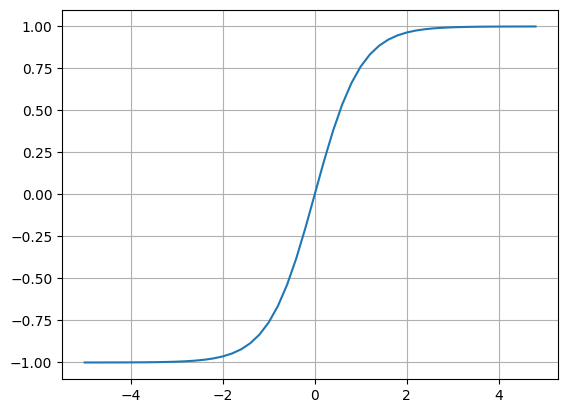

In [146]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [147]:
# Inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

In [148]:
# Manual gradients and backpropagation

# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2

o.grad = 1
n.grad = 0.5

x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad

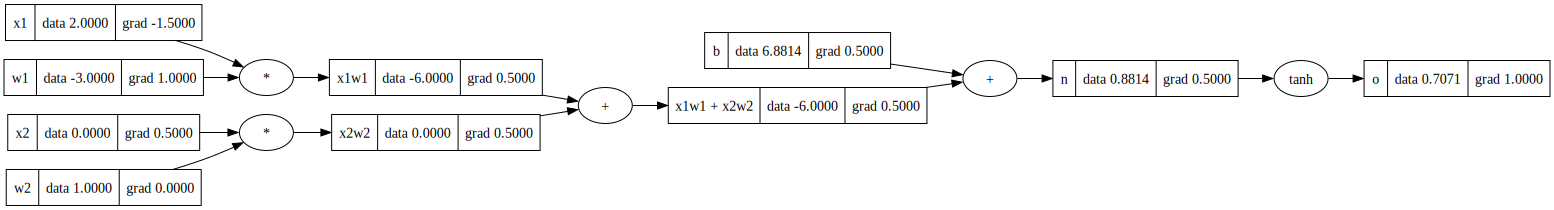

In [149]:
draw_dot(o)

In [150]:
# Now with autograd computation

# Inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

In [151]:
# Manual backpropagation calls

# o.grad = 1
# o.grad

# o._backward()

# n._backward()

# b._backward() # No effect because backward is None

# x1w1x2w2._backward()

# x1w1._backward()
# x2w2._backward()


In [152]:
o.backward()

visiting: o
visiting: n
visiting: b
Appending b to topo
visiting: x1w1 + x2w2
visiting: x1w1
visiting: w1
Appending w1 to topo
visiting: x1
Appending x1 to topo
Appending x1w1 to topo
visiting: x2w2
visiting: x2
Appending x2 to topo
visiting: w2
Appending w2 to topo
Appending x2w2 to topo
Appending x1w1 + x2w2 to topo
Appending n to topo
Appending o to topo
Calling _backward in o
Calling _backward in n
Calling _backward in x1w1 + x2w2
Calling _backward in x2w2
Calling _backward in w2
Calling _backward in x2
Calling _backward in x1w1
Calling _backward in x1
Calling _backward in w1
Calling _backward in b


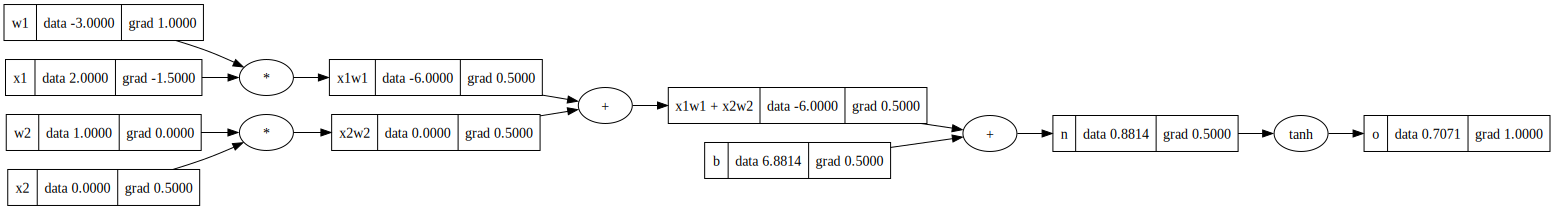

In [153]:
draw_dot(o)

visiting: b
visiting: a
Appending a to topo
Appending b to topo
Calling _backward in b
Calling _backward in a


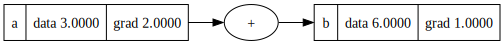

In [154]:
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

visiting: f
visiting: d
visiting: b
Appending b to topo
visiting: a
Appending a to topo
Appending d to topo
visiting: e
Appending e to topo
Appending f to topo
Calling _backward in f
Calling _backward in e
Calling _backward in d
Calling _backward in a
Calling _backward in b


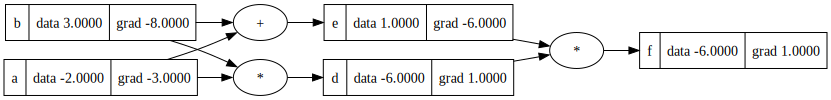

In [155]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

In [156]:
a = Value(2)

print(a + 1)
print(a * 2)
print( 2 * a)

Value(data=3, grad=0.0)
Value(data=4, grad=0.0)
Value(data=4, grad=0.0)


In [157]:
b = Value(2)

a/b

Value(data=1.0, grad=0.0)

In [158]:
a - b

Value(data=0, grad=0.0)

In [159]:
# Now with autograd computation, but tanh is computed from its atomic parts

# Inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'

# o = n.tanh(); o.label = 'o'
e = (2*n).exp(); e.label = 'e'
o = (e -1) / (e + 1); o.label = 'o'

o.backward()

visiting: o
visiting: 
visiting: 
visiting: 
Appending  to topo
visiting: e
visiting: 
visiting: n
visiting: b
Appending b to topo
visiting: x1w1 + x2w2
visiting: x2w2
visiting: x2
Appending x2 to topo
visiting: w2
Appending w2 to topo
Appending x2w2 to topo
visiting: x1w1
visiting: x1
Appending x1 to topo
visiting: w1
Appending w1 to topo
Appending x1w1 to topo
Appending x1w1 + x2w2 to topo
Appending n to topo
visiting: 
Appending  to topo
Appending  to topo
Appending e to topo
Appending  to topo
Appending  to topo
visiting: 
visiting: 
Appending  to topo
Appending  to topo
Appending o to topo
Calling _backward in o
Calling _backward in 
Calling _backward in 
Calling _backward in 
Calling _backward in 
Calling _backward in e
Calling _backward in 
Calling _backward in 
Calling _backward in n
Calling _backward in x1w1 + x2w2
Calling _backward in x1w1
Calling _backward in w1
Calling _backward in x1
Calling _backward in x2w2
Calling _backward in w2
Calling _backward in x2
Calling _backwar

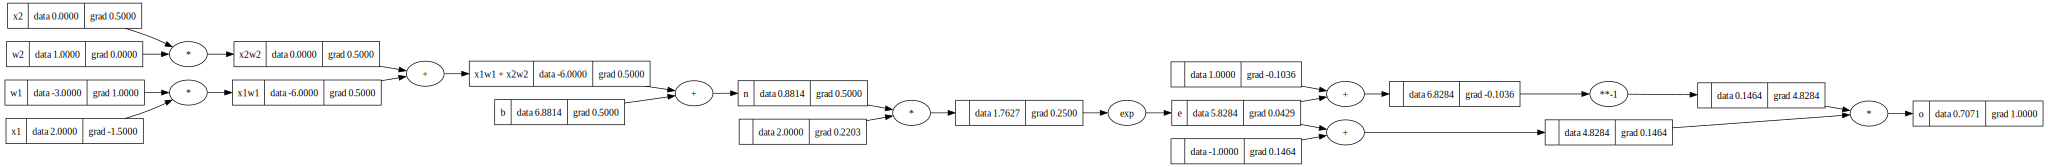

In [160]:
draw_dot(o)

In [161]:
# repeat the exercise but with PyTorch

import torch
import random

# Inputs x1, x2
x1 = torch.tensor([2.0], requires_grad = True) 
x2 = torch.tensor([0.0], requires_grad = True)
# weights w1 and w2
w1 = torch.tensor([-3.0], requires_grad = True)
w2 = torch.tensor([1.0], requires_grad = True)
# bias
b = torch.tensor([6.8813735870195432], requires_grad = True)

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())

o.backward()

print('-----')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())


0.7071067094802856
-----
x1 -1.5000003576278687
w1 1.000000238418579
x2 0.5000001192092896
w2 0.0


In [162]:
class Neuron:

    def __init__(self, n_inputs):
        self.w = [Value(random.uniform(-1,1)) for _ in range(n_inputs)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        activation = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = activation.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

In [163]:
class Layer:

    def __init__(self, n_inputs, n_output):
        self.neurons = [Neuron(n_inputs) for _ in range(n_output)] # n_output is equivalent to number of neurons in the layer

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        # Can be generated with list comprenhesion but keeping the loop for reference
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

In [164]:
class MLP:

    def __init__(self, n_inputs, n_outputs):
        layer_size = [n_inputs] + n_outputs # n_outputs is a list of the sizes of each layer
        self.layers = [Layer(layer_size[i], layer_size[i+1]) for i in range(len(n_outputs))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [165]:
x = [16.0, 23.0]
n = Neuron(2)
n(x) # internally calls __call__

Value(data=-0.9999999854122195, grad=0.0)

In [166]:
l = Layer(2, 3)
l(x)

[Value(data=0.9999999986801892, grad=0.0),
 Value(data=0.9915332602787413, grad=0.0),
 Value(data=-0.9999999999975134, grad=0.0)]

In [314]:
x = [12.0, 13.0, -16.0]

nn = MLP(3, [4, 4, 1])

nn(x)

Value(data=0.27880628864977425, grad=0.0)

In [315]:
nn.layers[0].neurons[0].w

[Value(data=-0.38199004818405946, grad=0.0),
 Value(data=0.4588851746498537, grad=0.0),
 Value(data=0.3212140310109952, grad=0.0)]

In [316]:
nn.layers[0].neurons[0].b

Value(data=0.9133395539048255, grad=0.0)

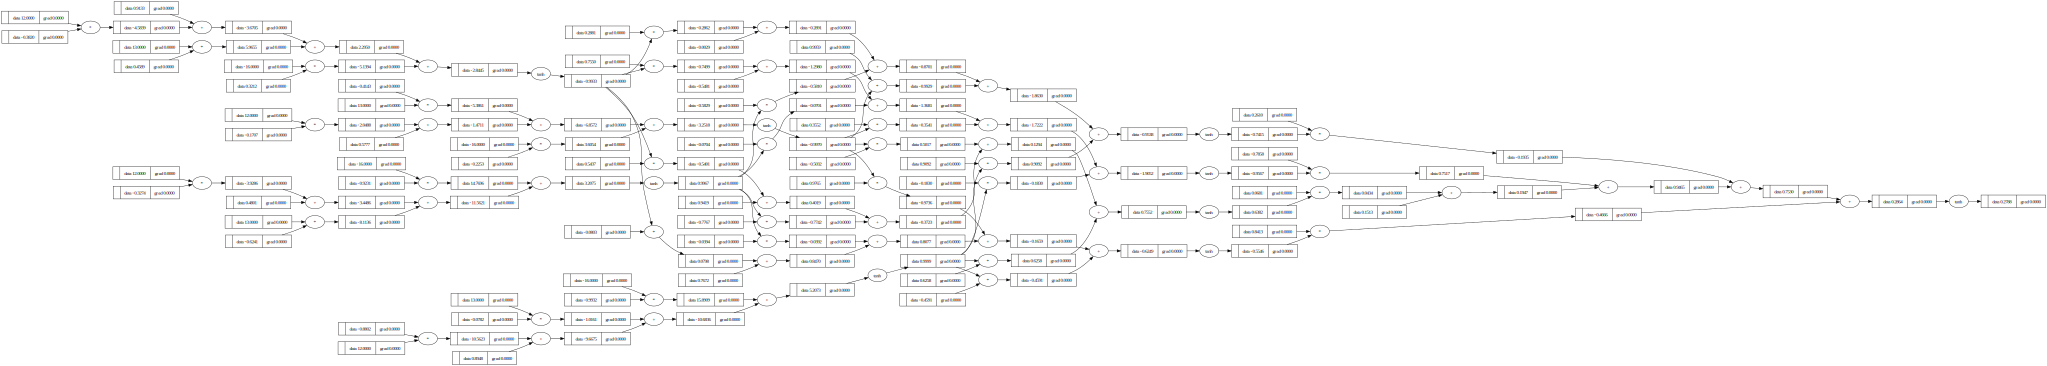

In [317]:
draw_dot(nn(x))

In [318]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

In [319]:
ypred = [nn(x) for x in xs]
ypred

[Value(data=0.3667652056992729, grad=0.0),
 Value(data=0.84415234662767, grad=0.0),
 Value(data=0.5587936266171896, grad=0.0),
 Value(data=0.7493277094909234, grad=0.0)]

In [320]:
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys,ypred)])
loss

Value(data=6.294558349896863, grad=0.0)

In [321]:
loss.backward()

visiting: 
visiting: 
visiting: 
visiting: 
visiting: 
visiting: 
visiting: 
visiting: 
visiting: 
visiting: 
Appending  to topo
visiting: 
visiting: 
visiting: 
visiting: 
Appending  to topo
visiting: 
Appending  to topo
Appending  to topo
visiting: 
visiting: 
visiting: 
Appending  to topo
visiting: 
visiting: 
Appending  to topo
visiting: 
Appending  to topo
Appending  to topo
Appending  to topo
visiting: 
visiting: 
Appending  to topo
visiting: 
Appending  to topo
Appending  to topo
Appending  to topo
Appending  to topo
Appending  to topo
Appending  to topo
visiting: 
visiting: 
visiting: 
visiting: 
Appending  to topo
visiting: 
visiting: 
visiting: 
visiting: 
Appending  to topo
visiting: 
Appending  to topo
Appending  to topo
visiting: 
visiting: 
visiting: 
visiting: 
Appending  to topo
visiting: 
Appending  to topo
Appending  to topo
visiting: 
Appending  to topo
Appending  to topo
visiting: 
visiting: 
Appending  to topo
visiting: 
Appending  to topo
Appending  to topo
Append

In [322]:
nn.layers[0].neurons[0].w

[Value(data=-0.38199004818405946, grad=-0.4613142741884066),
 Value(data=0.4588851746498537, grad=0.7357065882770294),
 Value(data=0.3212140310109952, grad=-0.6122167540332221)]

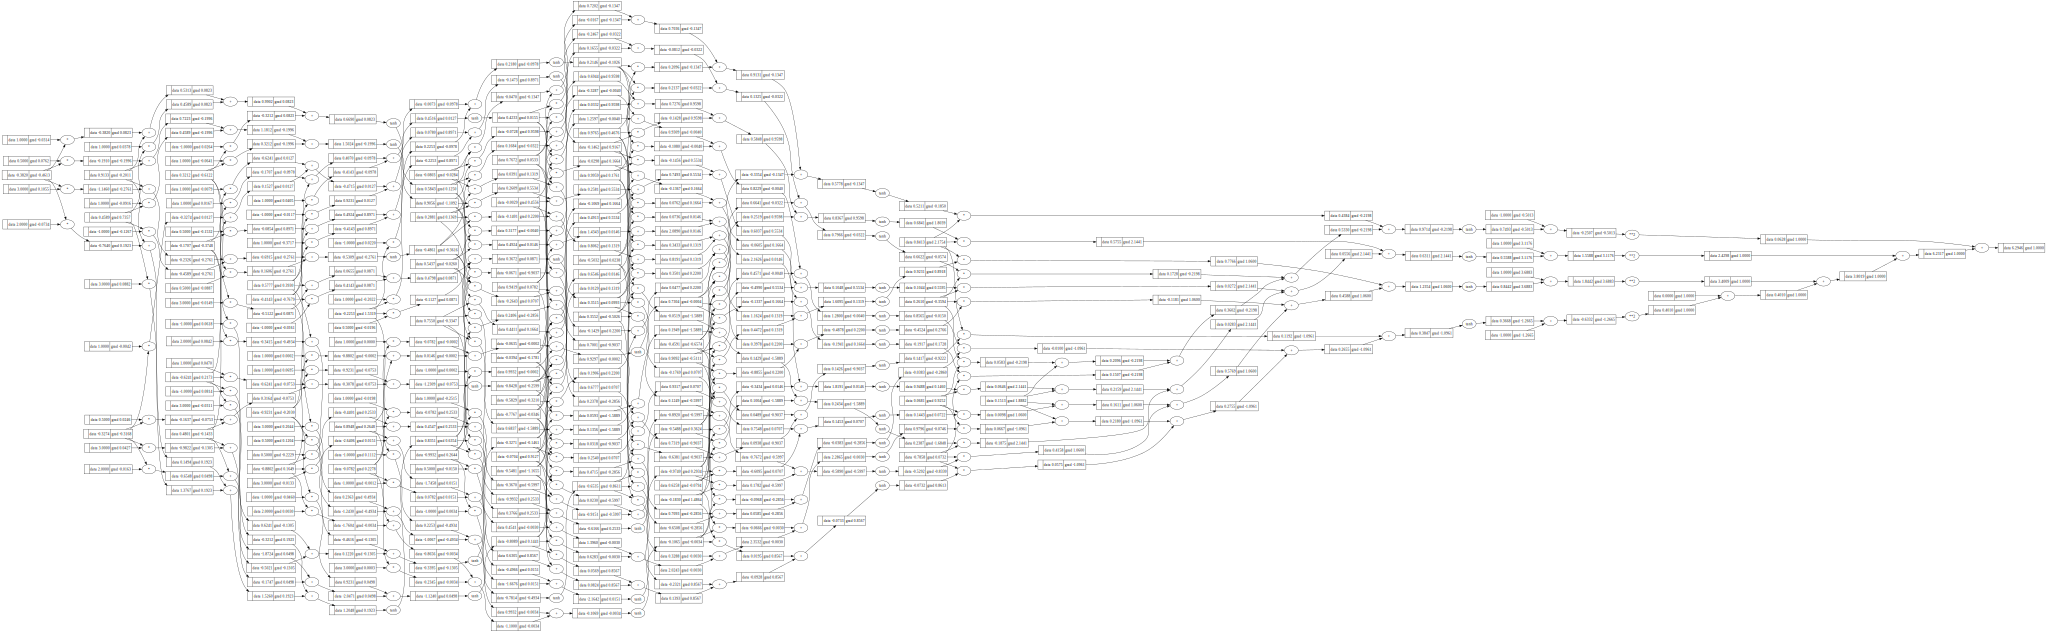

In [323]:
draw_dot(loss)

In [324]:
nn.parameters()

[Value(data=-0.38199004818405946, grad=-0.4613142741884066),
 Value(data=0.4588851746498537, grad=0.7357065882770294),
 Value(data=0.3212140310109952, grad=-0.6122167540332221),
 Value(data=0.9133395539048255, grad=-0.2011018928428991),
 Value(data=-0.32738429343405717, grad=-0.3167705376115008),
 Value(data=-0.6241210038316074, grad=0.21733510881724055),
 Value(data=-0.9231000743836517, grad=-0.20303007975443316),
 Value(data=0.48005479540560425, grad=-0.1432526038302731),
 Value(data=-0.1707363905957573, grad=-0.3748028138235028),
 Value(data=-0.41431809648460605, grad=-0.7678817241235142),
 Value(data=-0.2253379613822295, grad=1.5318594644501928),
 Value(data=0.5777235378923864, grad=0.3929920743299371),
 Value(data=-0.8801905335115254, grad=0.16488014387202082),
 Value(data=-0.07816183834232993, grad=0.2277839982034812),
 Value(data=-0.9931818928279617, grad=0.26438256030616475),
 Value(data=0.8948215852534094, grad=0.26475991202589416),
 Value(data=0.5437266999407631, grad=-0.0259

In [325]:
len(nn.parameters())

41

In [326]:
nn.layers[0].neurons[0].w[0].grad

-0.4613142741884066

In [327]:
nn.layers[0].neurons[0].w[0].data

-0.38199004818405946

In [328]:
for p in nn.parameters():
    p.data += -0.01 * p.grad # The gradient of the loss points towards the direction that increases the loss. We need to take a step in the opossite direction to reduce the loss.

In [329]:
nn.layers[0].neurons[0].w[0].data

-0.3773769054421754

In [330]:
# Loss before optimization step
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys,ypred)])
loss

Value(data=6.294558349896863, grad=0.0)

In [331]:
# Forward pass after optimization step

ypred = [nn(x) for x in xs]

In [332]:
# Loss after optimization step
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys,ypred)])
loss

Value(data=6.0858699803686305, grad=0.0)

In [333]:
# Taking a few steps 

learning_rate = 0.01

for i in range(250):
    print(f'--- Step: {i} ---')
    ypred = [nn(x) for x in xs]                                    # Forward pass
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys,ypred)])   # Calculate loss
    print(f'Loss = {loss}')
    if loss.data < 0.001:
        break
    for p in nn.parameters():                                      # zero.grad - flush the gradients of the previous step
        p.grad = 0.0 
    loss.backward(verbose=False)                                   # Packpropagation step
    for p in nn.parameters():                                      # Optimization step [update weights]
        p.data += -learning_rate * p.grad

--- Step: 0 ---
Loss = Value(data=6.0858699803686305, grad=0.0)
--- Step: 1 ---
Loss = Value(data=5.848540757872285, grad=0.0)
--- Step: 2 ---
Loss = Value(data=5.577899818028512, grad=0.0)
--- Step: 3 ---
Loss = Value(data=5.266731089654854, grad=0.0)
--- Step: 4 ---
Loss = Value(data=4.9034369644059765, grad=0.0)
--- Step: 5 ---
Loss = Value(data=4.4717589013469565, grad=0.0)
--- Step: 6 ---
Loss = Value(data=3.9588444269309973, grad=0.0)
--- Step: 7 ---
Loss = Value(data=3.3829961317472614, grad=0.0)
--- Step: 8 ---
Loss = Value(data=2.820544709835797, grad=0.0)
--- Step: 9 ---
Loss = Value(data=2.3525747636112384, grad=0.0)
--- Step: 10 ---
Loss = Value(data=1.9903896382378217, grad=0.0)
--- Step: 11 ---
Loss = Value(data=1.706104097683483, grad=0.0)
--- Step: 12 ---
Loss = Value(data=1.4752157488881341, grad=0.0)
--- Step: 13 ---
Loss = Value(data=1.2829947725722004, grad=0.0)
--- Step: 14 ---
Loss = Value(data=1.1208131267436827, grad=0.0)
--- Step: 15 ---
Loss = Value(data=0.983

In [334]:
ys

[1.0, -1.0, -1.0, 1.0]

In [335]:
ypred

[Value(data=0.9425458121067861, grad=-0.11490837578642776),
 Value(data=-0.9450091267180365, grad=0.10998174656392701),
 Value(data=-0.9381733995930371, grad=0.12365320081392572),
 Value(data=0.9485563831896378, grad=-0.1028872336207245)]